<a href="https://colab.research.google.com/github/AkankshaB123/ML/blob/main/K_Nearest_Neighbors.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# KNN

KNN stands for K-Nearest Neighbours. As the name suggests this algorithm tries to classify a new case based on K nearby points.

A Practical range for K is 2 to 10. If K=3, it means KNN will try to look for 3 nearest points.
It consists of 3 simple steps for any new point

    Find the most K number of similar(closest) points.
    Find the count of each class in those K points.
    Classify the new point as that class which is present the maximum number of times in these K points.
In the case of regression, take the average of nearest 'K' points.<br>
<a href="https://imgbb.com/"><img src="https://i.ibb.co/HF1T9qn/image-15.png" alt="image-15" border="0"></a><br>

As you can see in the figure. The cross is the new point and we choose K=3.
KNN will look at the nearby 3 points. It can be seen that 2 points are blue out of 3. Hence the new point is assigned to the blue class.

**The next question is, how does KNN find the nearest neighbour?**<br>
It does so by measuring distances between the points. Distance between two points can be calculated using any one of the below methods.
* **Euclidean Distance:** Take the difference between the coordinates of points and add it after squaring. E.g. Two points A(2,3) and B(6,5) will have a Euclidean distance of (2-6)2 + (3-5)2 = 20
$$
d_{euclidean} = \sqrt{\sum_{i=1}^{n}{(x_i - y_i)^2}}
$$

* **Manhattan Distance:** The sum of absolute differences between the coordinates of points. E.g. Two points A(2,3) and B(6,5) will have a Manhattan distance of |2-6| + |3-5| = 6
$$
d_{manhattan} = \sum_{i=1}^{n}{|x_i - y_i|}
$$

* **Minkowski Distance(default):** It is the generalization of both Euclidean and Manhattan Distance. A parameter “q” drives the behaviour of the below formula.<br>
    If q = 1, Manhattan Distance<br>
    If q = 2, Euclidean Distance<br>
$$
d_{minkowski} = (\sum_{i=1}^{n}{|x_i - y_i|^p})^{\frac{1}{p}}
$$

<h4> Ad click Project </h4>

Let us now start implementing what we learned from the previous section into python codes. We will use a website data of Customers to understand which customer will be click the AD, by the end of this section we will be able to make predictions using our "home-made" Logistic Regression.

This data set contains the following features:

* '`Daily Time Spent on Site`': consumer time on site in minutes
* '`Age`': cutomer age in years
* '`Area Income`': Avg. Income of geographical area of consumer
* '`Daily Internet Usage`': Avg. minutes a day consumer is on the internet
* '`Ad Topic Line`': Headline of the advertisement
* '`City`': City of consumer
* '`Male`': Whether or not consumer was male
* '`Country`': Country of consumer
* '`Timestamp`': Time at which consumer clicked on Ad or closed window
* '`Clicked on Ad`': 0 or 1 indicated clicking on Ad

In [ ]:
# !pip install -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 51.3 MB/s eta 0:00:0000:010:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.7/15.7 MB 37.3 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 55.9 MB/s eta 0:00:0000:010:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 288.2/288.2 kB 32.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.8/24.8 MB 25.2 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.1/38.1 MB 10.5 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 498.1/498.1 kB 43.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 54.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 965.4/965.4 kB 47.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 60.3 MB/s eta 0:00:00:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 298.0/298.0 kB 30.4 MB/s eta 0:00:00

[notice] A new release of pip available: 22.2.2 -> 22.3.1


In [ ]:
import pandas as pd
add_data=pd.read_csv("web_data.csv")
add_data.head()

,VistID,Time_Spent,Age,Avg_Income,Internet_Usage,Ad_Topic,Country_Name,City_Name,Sex,Time_Period,Weekday,Month,Year,Clicked
0,6286829,80.03,44,24030.06,150.84,11,0,83,0,5,2,3,2020,1
1,8572018,68.01,25,68357.96,188.32,24,0,329,1,2,0,2,2020,0
2,1101842,45.99,33,51163.14,124.61,10,0,807,1,5,2,1,2020,1
3,5774347,77.07,40,44559.43,261.02,24,0,824,0,3,5,5,2020,0
4,9737908,82.03,41,71511.08,187.53,22,0,707,0,0,1,6,2020,0


## Machine Learning: Splitting the data into Training and Testing sample
We dont use the full data for creating the model. Some data is randomly selected and kept aside for checking how good the model is. This is known as Testing Data and the remaining data is called Training data on which the model is built. Typically 70% of data is used as Training data and the rest 30% is used as Tesing data.

In [ ]:
# Separate Target Variable and Predictor Variables
TargetVariable='Clicked'
Predictors=['Time_Spent', 'Age', 'Avg_Income', 'Internet_Usage', 'Ad_Topic', 'Country_Name',
            'City_Name', 'Sex', 'Time_Period', 'Weekday', 'Month']

X=add_data[Predictors].values
y=add_data[TargetVariable].values

# Split the data into training and testing set
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Standardization/Normalization of data
This step if very important for KNN Algorithm.

In [ ]:
### Sandardization of data ###
from sklearn.preprocessing import StandardScaler, MinMaxScaler
# Choose either standardization or Normalization
# On this data Min Max Normalization produced better results

# Choose between standardization and MinMAx normalization
#PredictorScaler=StandardScaler()
PredictorScaler=MinMaxScaler()

# Storing the fit object for later reference
PredictorScalerFit=PredictorScaler.fit(X)

# Generating the standardized values of X
X=PredictorScalerFit.transform(X)

# Split the data into training and testing set
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Sanity check for the sampled data
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(5325, 11)
(5325,)
(1332, 11)
(1332,)


## Finding an Observation's Nearest Neighbors

In [ ]:
from sklearn.neighbors import NearestNeighbors

# nearest_neighbors = NearestNeighbors(n_neighbors=3).fit(X_train)
nearest_neighbors_euclidian = NearestNeighbors(n_neighbors=3, metric='euclidean').fit(X_train)

distances, indices = nearest_neighbors_euclidian.kneighbors(X_test[:1])

X_train[indices]

array([[[0.11779704, 0.14285714, 0.21427492, 0.06738104, 0.24137931,
         0.30932203, 0.32128099, 1.        , 0.2       , 0.        ,
         0.83333333],
        [0.12833588, 0.45238095, 0.37791163, 0.18222545, 0.55172414,
         0.78389831, 0.30991736, 1.        , 0.2       , 0.16666667,
         0.66666667],
        [0.2291348 , 0.26190476, 0.59134991, 0.09492675, 0.65517241,
         0.75423729, 0.11983471, 1.        , 0.        , 0.        ,
         0.66666667]]])

In [ ]:
distances

array([[0.49318183, 0.56817165]])

In [ ]:
indices

array([[ 534, 4213]])

In KNN, given an observation $x_u$, with an unknown target class, the algorithm first identifies the k closest observations (sometimes called $x_u$'s neighborhood) based on some distance metric, then these k observations "vote" based on their class and the class that wins the vote is $x_u$'s predicted class. More formally, the probability $x_u$ is some class j is:
$$
\frac{1}{k} \sum_{i \in v}{I(y_i = j)}
$$
where v is the k observatoin in $x_u$'s neighborhood, $y_i$ is the class of the ith observation, and I is an indicator function (i.e., 1 is true, 0 otherwise). In scikit-learn we can see these probabilities using `predict_proba`

In [ ]:
# K Nearest Neighbors - K = 5
# 5 nearest points -> Mode value
# Probability of both -> K - 2 : Class A , 3 : Class B
# Class B OR -> Class A -> 2/5 , Class B -> 3/5 -> 0.4, 0.6

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=3, n_jobs=-1)
# print the model
print(knn)

KNeighborsClassifier(n_jobs=-1, n_neighbors=3)


In [ ]:
KNN=knn.fit(X_train,y_train)
prediction=KNN.predict_probaproba(X_test)

In [ ]:
prediction # K = 3 , 2/3, 1/3

array([[0.        , 1.        ],
       [1.        , 0.        ],
       [0.        , 1.        ],
       ...,
       [0.66666667, 0.33333333],
       [0.        , 1.        ],
       [0.33333333, 0.66666667]])

In [ ]:
#Creating the model on Training Data
KNN=knn.fit(X_train,y_train)
prediction=KNN.predict(X_test)

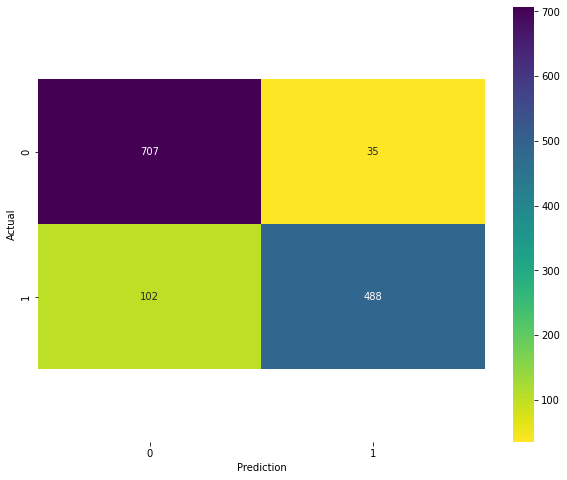

              precision    recall  f1-score   support

           0       0.87      0.95      0.91       742
           1       0.93      0.83      0.88       590

    accuracy                           0.90      1332
   macro avg       0.90      0.89      0.89      1332
weighted avg       0.90      0.90      0.90      1332



In [ ]:
# import necessary packages to measure model performace
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
# Checking Confusion Metrix
cnf_matrix = confusion_matrix(y_test, prediction)

# confusion metrics
plt.figure(figsize=(10,8))
ax = sns.heatmap(pd.DataFrame(cnf_matrix), annot = True, cmap = 'viridis_r', fmt = 'd')
bottom, top = ax.get_ylim()
ax.set_ylim(bottom + 0.5, top - 0.5)
plt.xlabel('Prediction')
plt.ylabel('Actual')
plt.show()

print(classification_report(y_test, prediction))

In [ ]:
# Printing the Overall Accuracy of the model
from sklearn.metrics import f1_score
F1_Score=f1_score(y_test, prediction, average='weighted')
print('Accuracy of the model on Testing Sample Data:', round(F1_Score,2))

Accuracy of the model on Testing Sample Data: 0.9


- KNN doesn't have feature importance feature.

## Identifying the Best Neighborhood Size

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

knn = KNeighborsClassifier()

pipe = Pipeline([("knn", knn)])

search_space = [{"knn__n_neighbors": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]}]

classifier = GridSearchCV(
    pipe, search_space, cv=5, verbose=0).fit(X_train, y_train)

classifier.best_estimator_.get_params()["knn__n_neighbors"]

9